# Aerodynamic coefficient tables for the reference vehicle

Builds $C_A$, $C_N$ and $C_m$ against Mach and incidence for every flight
configuration of the RS-28-class reference vehicle, from the meshes in
`data/vehicles/rs28/`.

**The sweep is checkpointed and resumable.** Every completed point is appended
to a newline-delimited JSON file the moment it finishes, and a run started
against an existing checkpoint evaluates only what is missing. `max_points` and
`time_budget` cut a long sweep into slices, and interrupting the kernel keeps
everything already computed. That is not a convenience: a CFD-backed table over
a fine grid is a multi-day job, and a design that can only be run to completion
in one sitting cannot be run at all.

## Which method, and where each one is allowed

No single method spans Mach 0 to 25, and pretending otherwise is how
coefficient tables go quietly wrong.

| regime | method | status |
| --- | --- | --- |
| $M < 1.05$ | compressible CFD or semi-empirical | **not covered here** |
| $1.05 < M < 4$ | Euler CFD (SU2), or panel with caution | panel runs, and is weakest here |
| $M > 4$ | modified Newtonian + Prandtl–Meyer panel | this notebook, ~10 % on axial force |

The panel method **refuses** subsonic input rather than returning a number: its
pressure closure blends a Newtonian windward branch with a Prandtl–Meyer
expansion, and neither exists below Mach 1. `SweepGrid.default_mach(minimum=…)`
trims a grid to a solver's range.

SU2 8.5.0 and gmsh 4.15.2 are installed. The axisymmetric-Euler path that would
fill the transonic gap is scaffolded in section 6 and **not yet validated** —
the honest state is recorded there rather than implied by a filled-in table.

## What the vehicle is

An RS-28 Sarmat class three-element vehicle — two main stages plus a powered
post-boost bus — 35.4 m long and 3.0 m in diameter. The mesh it came from was
repaired before use: its winding was inconsistent (the barrel wound outward,
all 2,000 nose facets inward, with the file's own stored normals agreeing with
the bad winding), and it carried interior geometry that a panel method would
otherwise integrate. Leaving the nozzle interior and the internal bulkheads in
gives the full stack an axial coefficient of **4.21** against **0.87** for the
same body without them.


## 1. Load the vehicle


In [1]:
import json
import pathlib
import time

import numpy as np
import matplotlib.pyplot as plt

from passes.aerodynamics.tables import (
    PanelSolver, SweepGrid, SweepRun, console_progress,
)
from passes.batch.backend import cuda_available
from passes.geometry import load_stl

VEHICLE = pathlib.Path("../data/vehicles/rs28")
STORE = pathlib.Path("../results/aero")
STORE.mkdir(parents=True, exist_ok=True)
BACKEND = "cupy" if cuda_available() else "numpy"

manifest = json.loads((VEHICLE / "manifest.json").read_text())
print(manifest["name"])
print(f"  source            {manifest['source_mesh']['file']}")
print(f"  sha256            {manifest['source_mesh']['sha256'][:16]}...")
print(f"  length            {manifest['measured']['length_m']:.3f} m")
print(f"  wetted area       {manifest['measured']['wetted_area_m2']:.2f} m2")
print(f"  frontal area      {manifest['measured']['frontal_area_m2']:.3f} m2")
print(f"  nose exponent     {manifest['measured']['nose_exponent']:.3f}  "
      f"({manifest['measured']['nose_shape']})")
print(f"  backend           {BACKEND}")
print()
for defect in manifest["source_mesh"]["defects_repaired"]:
    print(f"  repaired: {defect}")


RS-28 Sarmat (15A28) — representative model
  source            reference/model.stl
  sha256            d77ea63b45d5a5f4...
  length            35.400 m
  wetted area       327.55 m2
  frontal area      7.038 m2
  nose exponent     0.591  (power-law ogive (0.5 would be a sphere, 1.0 a cone))
  backend           cupy

  repaired: inconsistent winding: barrel wound outward, all 2000 nose facets wound inward, and the stored facet normals agreed with the bad winding. Repaired by per-face parity with a 7-ray majority vote.
  repaired: 3 zero-area facets dropped on load.


### Reference quantities

Coefficients are non-dimensionalised on the **full vehicle's** maximum
cross-section and its diameter — not on each configuration's own. Otherwise the
stack's axial coefficient and the payload's are divided by different numbers and
cannot be compared, blended across staging, or handed to a trajectory that flies
through both.


In [2]:
DIAMETER = manifest["published"]["diameter_m"]
REFERENCE_AREA = np.pi * DIAMETER**2 / 4.0
REFERENCE_LENGTH = DIAMETER

CONFIGURATIONS = [
    row for row in manifest["components"] if row["kind"] == "configuration"
]
print(f"reference area {REFERENCE_AREA:.4f} m2, reference length {REFERENCE_LENGTH:.2f} m\n")
print(f"{'configuration':18}{'faces':>7}{'length m':>10}{'wetted m2':>11}{'frontal m2':>12}")
for row in CONFIGURATIONS:
    print(f"{row['name']:18}{row['faces']:7d}{row['length_m']:10.2f}"
          f"{row['wetted_area_m2']:11.2f}{row['frontal_area_m2']:12.3f}")


reference area 7.0686 m2, reference length 3.00 m

configuration       faces  length m  wetted m2  frontal m2
full-stack           6311     35.40     304.58       7.038
after-stage1         3466     13.56     111.36       7.038
after-stage2         2589      6.89      51.83       6.826
payload-only         2120      3.30      22.61       6.090


## 2. The sweep grid

Deliberately non-uniform in Mach. A `linspace` spends most of its points above
Mach 10 where the curves are flat and skips the transonic bucket where they are
not; this grid is dense from 0.6 to 1.6 and coarsens upward. The panel solver
only sees the part above its floor.


In [3]:
FULL_MACH = SweepGrid.default_mach()
PANEL_MACH = SweepGrid.default_mach(minimum=1.2)
ALPHA = SweepGrid.default_alpha(limit_deg=12.0, step_deg=1.0)

grid = SweepGrid(mach=PANEL_MACH, alpha=ALPHA)
print(f"full grid         {FULL_MACH.size} Mach x {ALPHA.size} alpha")
print(f"panel-eligible    {PANEL_MACH.size} Mach x {ALPHA.size} alpha = {grid.size} points")
print(f"not covered       {FULL_MACH.size - PANEL_MACH.size} subsonic/transonic Mach values")
print(f"                  {np.round(FULL_MACH[FULL_MACH < 1.2], 2).tolist()}")
print()
print(f"per configuration {grid.size} points, {len(CONFIGURATIONS)} configurations "
      f"= {grid.size * len(CONFIGURATIONS)} total")


full grid         47 Mach x 13 alpha
panel-eligible    32 Mach x 13 alpha = 416 points
not covered       15 subsonic/transonic Mach values
                  [0.3, 0.4, 0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15]

per configuration 416 points, 4 configurations = 1664 total


## 3. Run — resumably

Each configuration gets its own checkpoint. Re-running this cell after an
interruption picks up exactly where it stopped; running it after completion does
nothing and returns the tables from disk.

To run a slice instead of the whole thing, pass `max_points=` or `time_budget=`
to `run()`. Both are honoured mid-sweep and leave a valid partial checkpoint.


In [4]:
MAX_POINTS = None      # e.g. 200 to take a slice
TIME_BUDGET = None     # e.g. 60.0 seconds

runs, tables = {}, {}
started = time.perf_counter()
for row in CONFIGURATIONS:
    name = row["name"]
    mesh = load_stl(VEHICLE / row["file"])
    solver = PanelSolver(mesh, REFERENCE_AREA, REFERENCE_LENGTH)
    run = SweepRun(
        name=name, grid=grid, solver=solver,
        store=STORE / f"panel-{name}.jsonl",
        reference_area=REFERENCE_AREA, reference_length=REFERENCE_LENGTH,
        metadata={"mesh": row["file"], "faces": row["faces"]},
    )
    before = run.status()
    runs[name] = run
    tables[name] = run.run(
        progress=console_progress(), max_points=MAX_POINTS, time_budget=TIME_BUDGET
    )
    after = run.status()
    print(f"    {name:18s} {before['completed']:4d} -> {after['completed']:4d} "
          f"of {after['total']}  complete={tables[name].complete}")
print(f"\nwall time {time.perf_counter() - started:.1f} s")


  full-stack             [##################################]   416/416   100.0%     4.98 pt/s  ETA   0m00s


    full-stack            0 ->  416 of 416  complete=True


  after-stage1           [##################################]   416/416   100.0%     9.60 pt/s  ETA   0m00s


    after-stage1          0 ->  416 of 416  complete=True


  after-stage2           [##################################]   416/416   100.0%    13.27 pt/s  ETA   0m00s


    after-stage2          0 ->  416 of 416  complete=True


  payload-only           [##################################]   416/416   100.0%    16.77 pt/s  ETA   0m00s


    payload-only          0 ->  416 of 416  complete=True

wall time 183.0 s


### Status at a glance


In [5]:
print(f"{'configuration':18}{'done':>7}{'total':>7}{'pct':>7}  checkpoint")
for name, run in runs.items():
    s = run.status()
    print(f"{name:18}{s['completed']:7d}{s['total']:7d}{100 * s['fraction']:6.1f}%  "
          f"{pathlib.Path(s['store']).name}")


configuration        done  total    pct  checkpoint
full-stack            416    416 100.0%  panel-full-stack.jsonl
after-stage1          416    416 100.0%  panel-after-stage1.jsonl
after-stage2          416    416 100.0%  panel-after-stage2.jsonl
payload-only          416    416 100.0%  panel-payload-only.jsonl


## 4. The tables

Axial force first, because it is what a trajectory actually needs and what the
flight simulator currently takes as a hand-set `drag_area`.


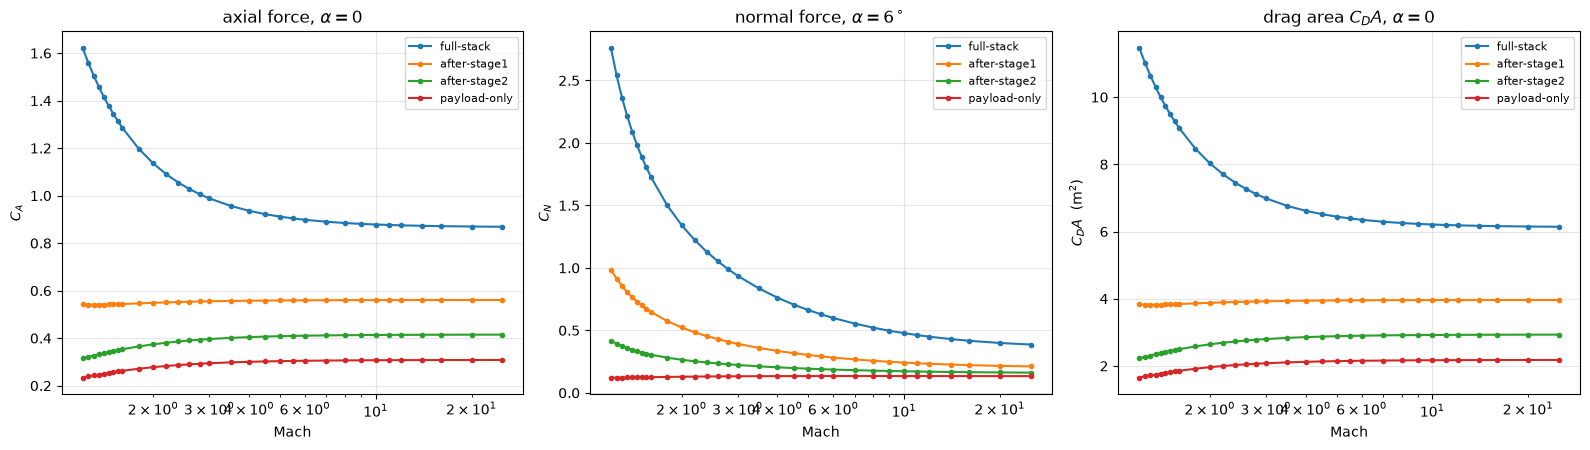

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

for name, table in tables.items():
    axes[0].plot(table.mach, table.axial[:, 0], marker="o", ms=3, label=name)
    axes[1].plot(table.mach, table.normal[:, 6], marker="o", ms=3, label=name)
    axes[2].plot(table.mach, [table.drag_area(float(m)) for m in table.mach],
                 marker="o", ms=3, label=name)

for ax, title, ylabel in zip(
    axes,
    ["axial force, $\\alpha = 0$", "normal force, $\\alpha = 6^\\circ$",
     "drag area $C_D A$, $\\alpha = 0$"],
    ["$C_A$", "$C_N$", "$C_D A$  (m$^2$)"],
):
    ax.set_xlabel("Mach"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    ax.set_xscale("log")
plt.tight_layout(); plt.show()


The payload's axial coefficient **rises** with Mach while the full stack's falls,
and both are correct. A nose-dominated body follows $C_{p,\max}$, which climbs
toward the Newtonian limit of 1.84; the stack is dominated at low supersonic by
the expansion over its long afterbody, which weakens as Mach grows. What both
must do is *settle*, and they do — the change from Mach 14 to 25 is under a
percent.


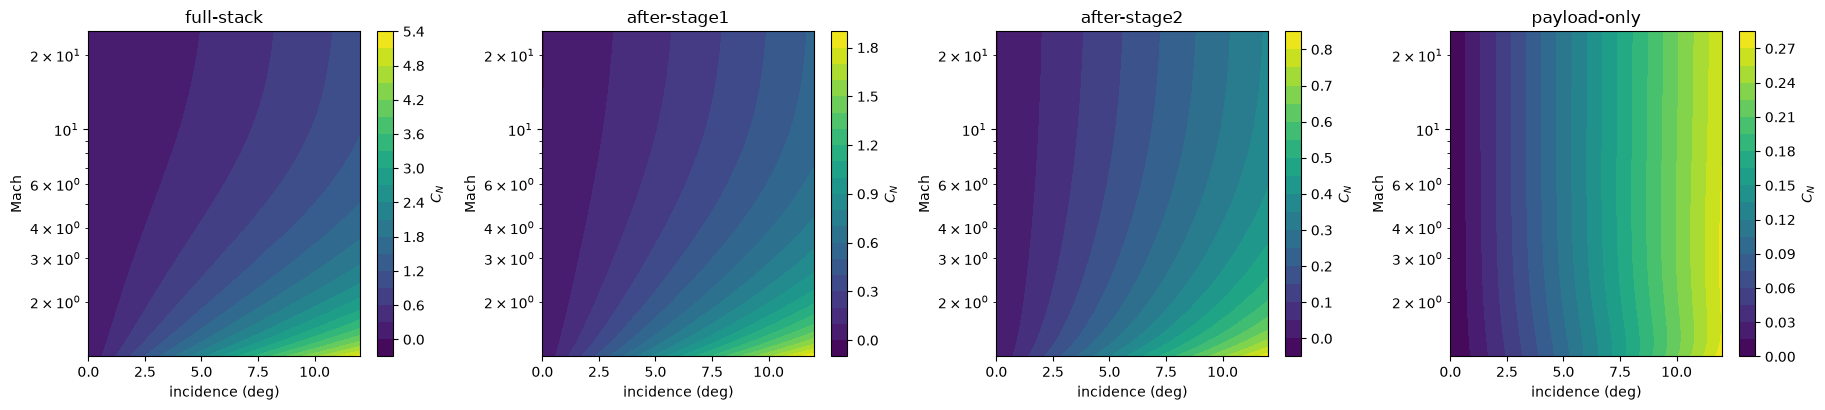

In [7]:
fig, axes = plt.subplots(1, len(tables), figsize=(4.6 * len(tables), 4.2), squeeze=False)
for ax, (name, table) in zip(axes[0], tables.items()):
    mesh_grid = ax.contourf(
        np.rad2deg(table.alpha), table.mach, table.normal, levels=18, cmap="viridis"
    )
    fig.colorbar(mesh_grid, ax=ax, label="$C_N$")
    ax.set_xlabel("incidence (deg)"); ax.set_ylabel("Mach")
    ax.set_yscale("log"); ax.set_title(name)
plt.tight_layout(); plt.show()


### Numbers, for the record


In [8]:
sample_mach = [1.2, 1.5, 2.0, 3.0, 5.0, 10.0, 20.0, 25.0]
for name, table in tables.items():
    print(f"\n{name}   (reference area {table.reference_area:.4f} m2)")
    print(f"  {'Mach':>6}{'C_A(0)':>10}{'C_N(6d)':>10}{'C_m(6d)':>10}{'C_D*A m2':>11}")
    for m in sample_mach:
        c0 = table.at(m, 0.0)
        c6 = table.at(m, np.deg2rad(6.0))
        print(f"  {m:6.1f}{c0.axial:10.4f}{c6.normal:10.4f}"
              f"{c6.pitching_moment:10.4f}{table.drag_area(m):11.3f}")



full-stack   (reference area 7.0686 m2)
    Mach    C_A(0)   C_N(6d)   C_m(6d)   C_D*A m2
     1.2    1.6223    2.7613  -16.7110     11.467
     1.5    1.3434    1.8872  -11.2563      9.496
     2.0    1.1357    1.3428   -7.8442      8.028
     3.0    0.9885    0.9373   -5.3004      6.987
     5.0    0.9117    0.6627   -3.5824      6.444
    10.0    0.8784    0.4777   -2.4297      6.209
    20.0    0.8700    0.3991   -1.9418      6.149
    25.0    0.8689    0.3865   -1.8637      6.142

after-stage1   (reference area 7.0686 m2)
    Mach    C_A(0)   C_N(6d)   C_m(6d)   C_D*A m2
     1.2    0.5420    0.9859   -2.5155      3.832
     1.5    0.5425    0.6994   -1.7071      3.834
     2.0    0.5487    0.5233   -1.2042      3.878
     3.0    0.5551    0.3924   -0.8295      3.924
     5.0    0.5587    0.3030   -0.5755      3.949
    10.0    0.5601    0.2420   -0.4039      3.959
    20.0    0.5605    0.2158   -0.3308      3.962
    25.0    0.5605    0.2116   -0.3191      3.962

after-stage2   

## 5. Feeding the trajectory

`FlightConfiguration.drag_area` was a hand-set constant. This is where it should
come from — and the point of building every configuration on one reference area
is that a trajectory can switch tables at staging without renormalising.


In [9]:
for name, table in tables.items():
    print(f"{name:18}", end="")
    for m in (2.0, 5.0, 10.0, 20.0):
        print(f"  M{m:<4.0f} {table.drag_area(m):6.3f}", end="")
    print("  m2")
print()
print("The simulator takes one number; a table gives it the whole curve.")
print("A constant drag area is a choice of Mach, usually an unstated one.")


full-stack          M2     8.028  M5     6.444  M10    6.209  M20    6.149  m2
after-stage1        M2     3.878  M5     3.949  M10    3.959  M20    3.962  m2
after-stage2        M2     2.643  M5     2.885  M10    2.922  M20    2.931  m2
payload-only        M2     1.963  M5     2.143  M10    2.170  M20    2.177  m2

The simulator takes one number; a table gives it the whole curve.
A constant drag area is a choice of Mach, usually an unstated one.


## 6. The transonic gap, and what would close it

Everything above stops at Mach 1.2. The gap matters: a launch vehicle spends its
highest dynamic pressure between Mach 0.8 and 1.5, so the part of the curve this
notebook does not cover is the part that sizes the structure.

**SU2 8.5.0 and gmsh 4.15.2 are installed and verified.** The path that would
close the gap is axisymmetric Euler, and it is cheap for one specific reason:
this vehicle is a body of revolution, so at $\alpha = 0$ the problem is
two-dimensional — a few thousand cells and seconds per point, for the entire
$C_A(M)$ curve at genuine CFD fidelity. Only $C_N$ and $C_m$ need three
dimensions, and normal force is the coefficient the panel method already handles
well.

Three things remain, and none is a formality:

1. **Meshing.** Extract the station profile, build an axisymmetric domain in
   gmsh with a shock-resolving boundary layer and a far field ten body lengths
   out, export SU2 format.
2. **Boundary conditions.** `SOLVER=EULER`, `AXISYMMETRIC=YES`, a slip wall on
   the body, a symmetry plane on the axis, a Riemann far field.
3. **Validation.** A grid-convergence study and a check against a case with a
   known answer — a sharp cone at a Mach number with a Taylor–Maccoll solution
   is the standard choice. Without that the numbers are decoration.

Skin friction is *not* in an Euler solution and has to be added separately, by a
Van Driest II flat-plate correlation over the wetted area.

The cell below confirms the toolchain and states plainly what is not done.


In [10]:
import shutil
import subprocess

su2 = pathlib.Path("/config/miniconda3/envs/su2/bin/SU2_CFD")
print("toolchain")
if su2.exists():
    version = subprocess.run([str(su2), "--help"], capture_output=True, text=True)
    print(f"  SU2      {version.stdout.splitlines()[0]}")
else:
    print("  SU2      NOT FOUND")
try:
    import gmsh
    gmsh.initialize(); print(f"  gmsh     {gmsh.option.getString('General.Version')}")
    gmsh.finalize()
except Exception as exc:
    print(f"  gmsh     unavailable: {exc}")

print()
print("status: the axisymmetric Euler pipeline is NOT built and NOT validated.")
print("        Nothing in this notebook depends on it; the tables above are")
print("        panel-method results above Mach 1.2 and say so.")


toolchain
  SU2      SU2 v8.5.0 "Harrier", The Open-Source CFD Code
  gmsh     4.15.2

status: the axisymmetric Euler pipeline is NOT built and NOT validated.
        Nothing in this notebook depends on it; the tables above are
        panel-method results above Mach 1.2 and say so.


## Limitations

- **Above Mach 1.2 only.** The panel method has no subsonic branch and refuses
  to pretend otherwise.
- **Inviscid.** Modified Newtonian gives pressure forces. Skin friction is
  absent, which matters most where it is largest — the long, slender afterbody
  at low supersonic — and is a systematic *under*-estimate of axial force there.
- **No base drag.** Panels facing aft are shadowed and contribute nothing, so
  the base pressure deficit of a real body is missing. Also an under-estimate.
- **~10 % on axial force above Mach 5**, and worse below. Impact theory is a
  preliminary-design method; these tables are for trajectory work, not loads.
- **The geometry is representative, not faithful.** The source mesh was 15.6 %
  oversized in diameter and has been scaled to the published 3.0 m; its ring
  positions still imply stage proportions that only work under the volumetric
  reading recorded in the manifest.
- **Coefficients are referenced to the nose**, not to a centre of mass. Static
  margin needs the mass model in `passes.systems.mass`, whose centre of mass
  moves several metres during the first burn.
